In [1]:
import pandas as pd
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
mat = scipy.io.loadmat('Xtrain.mat')

In [3]:
df = pd.DataFrame(mat['Xtrain'])

In [4]:
df.head()

,0
0,86
1,141
2,95
3,41
4,22


In [5]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[ 5.57201545e-01],
       [ 1.73111118e+00],
       [ 7.49295849e-01],
       [-4.03269976e-01],
       [-8.08802396e-01],
       [-8.30146207e-01],
       [-5.95364280e-01],
       [ 2.58388183e-01],
       [ 1.66707975e+00],
       [ 1.09079683e+00],
       [-2.53863295e-01],
       [-7.87458584e-01],
       [-8.72833830e-01],
       [-7.02083338e-01],
       [-1.90813675e-02],
       [ 1.47498544e+00],
       [ 1.47498544e+00],
       [-4.04251791e-02],
       [-7.02083338e-01],
       [-8.72833830e-01],
       [-7.66114772e-01],
       [-2.96550918e-01],
       [ 1.11214065e+00],
       [ 1.79514262e+00],
       [ 2.79731994e-01],
       [-6.38051903e-01],
       [-8.51490019e-01],
       [-8.72833830e-01],
       [-4.88645222e-01],
       [ 6.85264414e-01],
       [ 1.96589311e+00],
       [ 7.06608226e-01],
       [-5.09989034e-01],
       [-8.51490019e-01],
       [-8.94177642e-01],
       [-6.59395715e-01],
       [ 2.37044371e-01],
       [ 1.83783024e+00],
       [ 1.2

# Plot

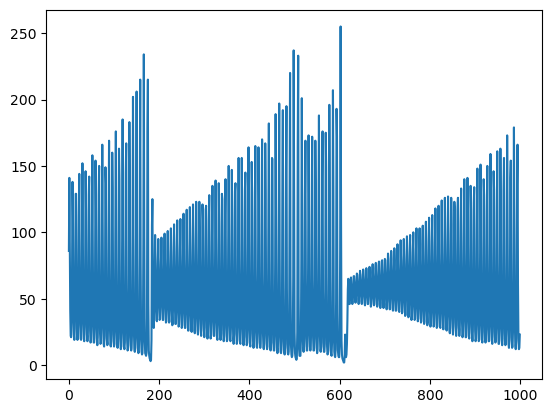

In [6]:
Y = df.values
X = range(len(Y))

plt.plot(X, Y)

# Model

In [7]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Fit ARIMA model
# (p, d, q) = (autoregressive order, differencing order, moving average order)
arima_model = ARIMA(df.values.flatten(), order=(50, 1, 50))
arima_fit = arima_model.fit()

print(arima_fit.summary())

c:\Users\matth\anaconda3\envs\DL\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\matth\anaconda3\envs\DL\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\matth\anaconda3\envs\DL\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               ARIMA(50, 1, 50)   Log Likelihood               -4886.672
Date:                Thu, 30 Apr 2026   AIC                           9975.343
Time:                        12:05:52   BIC                          10470.926
Sample:                             0   HQIC                         10163.708
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4602      0.866     -1.685      0.092      -3.158       0.238
ar.L2          0.0984      0.770      0.128      0.898      -1.410       1.607
ar.L3          1.6387      1.426      1.149      0.2

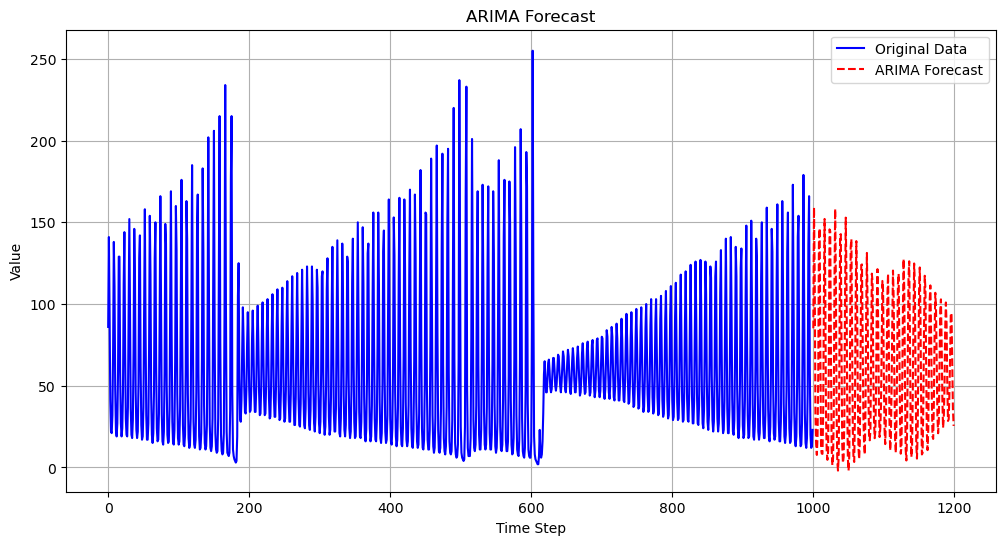

In-sample RMSE: 21.5105


In [8]:
# Forecast next 50 steps
forecast_steps = 200
arima_forecast = arima_fit.forecast(steps=forecast_steps)

# Plot original data and ARIMA forecast
plt.figure(figsize=(12, 6))
plt.plot(range(len(df)), df.values.flatten(), label='Original Data', color='blue')
plt.plot(range(len(df), len(df) + forecast_steps), arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('ARIMA Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Calculate RMSE on training data (in-sample)
train_pred = arima_fit.fittedvalues
rmse = np.sqrt(mean_squared_error(df.values.flatten()[1:], train_pred[1:]))
print(f"In-sample RMSE: {rmse:.4f}")

# LSTM

In [11]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from sklearn.preprocessing import MinMaxScaler

# # Prepare data for LSTM
# data = df.values.flatten()

# # Scale the data
# lstm_scaler = MinMaxScaler(feature_range=(0, 1))
# scaled_data = lstm_scaler.fit_transform(data.reshape(-1, 1))

# # Create sequences
# def create_sequences(data, seq_length):
#     X, y = [], []
#     for i in range(len(data) - seq_length):
#         X.append(data[i:i+seq_length])
#         y.append(data[i+seq_length])
#     return np.array(X), np.array(y)

# seq_length = 50
# X_lstm, y_lstm = create_sequences(scaled_data, seq_length)

# # Reshape for LSTM [samples, time steps, features]
# X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

# # Build LSTM model
# model = Sequential([
#     LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
#     Dropout(0.2),
#     LSTM(32, return_sequences=False),
#     Dropout(0.2),
#     Dense(16, activation='relu'),
#     Dense(1)
# ])

# model.compile(optimizer='adam', loss='mse')
# model.summary()

# # Train the model
# history = model.fit(
#     X_lstm, y_lstm,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.2,
#     verbose=1
# )

# Moving average test